In [348]:
import pandas as pd 
import xarray as xr 
import geopandas as gpd
import numpy as np 
import functions.funcs as func 
import matplotlib.pyplot as plt

In [349]:
ds = gpd.read_parquet(r"Data\Mappedwinds_SAT_MI_Cleanedspeeds.parquet")

In [350]:
windu = func.Column_to_List(ds, "mapped_u_oscar")
windv = func.Column_to_List(ds, "mapped_v_oscar")
oceanu = func.Column_to_List(ds, "mapped_u")
oceanv = func.Column_to_List(ds, "mapped_v")
FADu = func.Column_to_List(ds, "x_speed")
FADv = func.Column_to_List(ds, "y_speed")
longlist = pd.DataFrame({"windu" : windu, "windv": windv, "oceanu": oceanu, 'oceanv': oceanv, 'dfadu' : FADu , 'dfadv' : FADv})

In [351]:
dot = longlist.windu*longlist.oceanu + longlist.windv*longlist.oceanv
dot_dfad = longlist.windu*longlist.dfadu + longlist.dfadv*longlist.windv

wind_mag  = np.sqrt(longlist.windu**2 + longlist.windv**2)
ocean_mag = np.sqrt(longlist.oceanu**2 + longlist.oceanv**2)
dfad_mag = np.sqrt(longlist.dfadv**2, longlist.dfadu**2)
longlist["ocean_angle"] = np.arccos(dot/wind_mag/ocean_mag)*180/(np.pi)
longlist["dfad_angle"] = np.arccos(dot_dfad/wind_mag/dfad_mag)*180/(np.pi)

c:\Users\czerfass\AppData\Local\miniforge3\envs\parcels\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)


Text(0.5, 1.0, 'Angle Between Wind and dFAD')

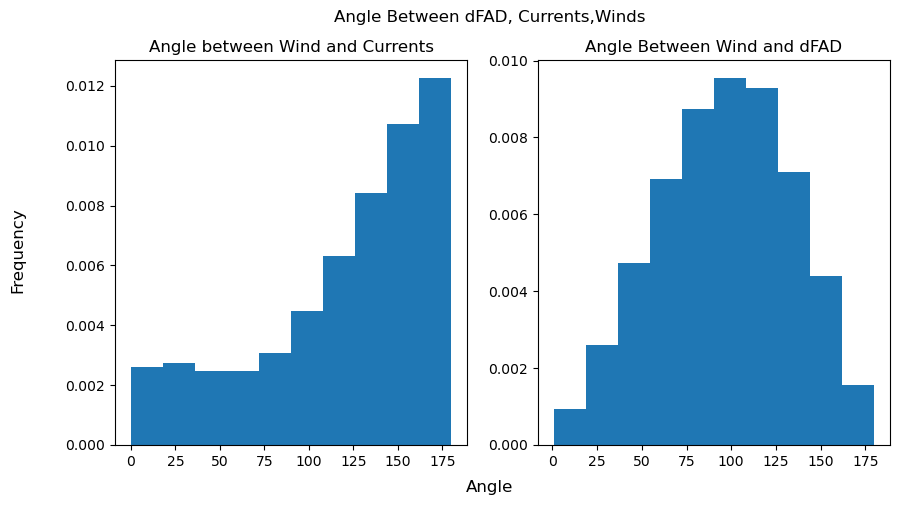

In [352]:
fig, ax = plt.subplots(1,2, figsize = (10,5))
ax[0].hist(longlist.ocean_angle, density=True)
ax[1].hist(longlist.dfad_angle, density=True)
fig.suptitle("Angle Between dFAD, Currents,Winds")
fig.supxlabel("Angle")
fig.supylabel("Frequency")
ax[0].set_title("Angle between Wind and Currents")
ax[1].set_title("Angle Between Wind and dFAD")

## Calculating complex correlation coefficient

$$ R = \frac {<U^* W>} {\sqrt{<U^* U > <W^* W>}}

In [353]:
def umean(row):
    x_speeds = np.array(row.x_speed.mean())
    return x_speeds.mean()
def vmean(row):
    y_speeds = np.array(row.y_speed.mean())
    return y_speeds.mean()

def umeanwind(row):
    x_speeds = np.array(row.mapped_u_oscar.mean())
    return x_speeds.mean()
def vmeanwind(row):
    y_speeds = np.array(row.mapped_v_oscar.mean())
    return y_speeds.mean()

def umeanocean(row):
    x_speeds = np.array(row.mapped_u.mean())
    return x_speeds.mean()
def vmeanocean(row):
    y_speeds = np.array(row.mapped_v.mean())
    return y_speeds.mean()


ds["u_mean"] = ds.apply(umean, axis = 1)
ds["v_mean"] = ds.apply(vmean, axis = 1)
ds["u_mean_wind"] = ds.apply(umeanwind, axis = 1)
ds["v_mean_wind"] = ds.apply(vmeanwind, axis = 1)
ds["u_mean_ocean"] = ds.apply(umeanocean, axis = 1)
ds["v_mean_ocean"] = ds.apply(vmeanocean, axis = 1)


ds["u_hat"] = ds.apply(lambda row: row.x_speed - row.u_mean, axis =1)
ds["v_hat"] = ds.apply(lambda row: row.y_speed - row.v_mean, axis =1)
ds["u_wind_hat"] = ds.apply(lambda row: row.mapped_u_oscar- row.u_mean_wind, axis =1 )
ds["v_wind_hat"] = ds.apply(lambda row: row.mapped_v_oscar- row.v_mean_wind, axis =1 )

ds["u_current_hat"] = ds.apply(lambda row: row.mapped_u- row.u_mean_ocean, axis =1 )
ds["v_current_hat"] = ds.apply(lambda row: row.mapped_v- row.v_mean_ocean, axis =1 )

### Calcuating R for indivgiual trajecotry.
ds["U"] = ds["u_hat"] + 1j*ds["v_hat"]
ds["W"] = ds["u_wind_hat"] + 1j*ds["v_wind_hat"]
ds["Uo"] = ds["u_current_hat"] +1j*ds['v_current_hat']
ds['U*'] = np.conj(ds["U"])
ds['W*'] = np.conj(ds["W"])
ds['Uo*'] = np.conj(ds["Uo"])
def calc_R(row):
    num = np.mean(row["U*"]*row['W'])
    a = np.mean(row['U*']*row["U"])
    b = np.mean(row['W*']*row["W"])
    return num/np.sqrt(a*b)
def calc_R_ocean(row):
    num = np.mean(row["U*"]*row['Uo'])
    a = np.mean(row['U*']*row["U"])
    b = np.mean(row['Uo*']*row["U"])
    return num/np.sqrt(a*b)

def calc_R_windmodel(row):
    num = np.mean(row["Uo*"]*row['W'])
    a = np.mean(row["Uo*"]*row['Uo'])
    b = np.mean(row['W*']*row['W'])
    return num/np.sqrt(a*b)

def calc_R_anything(U, W):
    num = np.mean(np.conjugate(U)*W)
    a = np.mean(np.conjugate(U)*U)
    b = np.mean(np.conjugate(W)*W)
    return num/np.sqrt(a*b)


ds["R"] = ds.apply(calc_R, axis = 1)
ds["R_ocean"] = ds.apply(calc_R_ocean, axis = 1)

In [354]:
ds["num_points"] = ds.apply(lambda row : len(row.TimeStamp), axis = 1)
ds2 = ds.query("num_points > 10").reset_index(drop = True)

In [355]:
longlist2 = pd.DataFrame()
longlist2["U"] = func.Column_to_List(ds2, "U")
longlist2["U*"] = func.Column_to_List(ds2, "U*")
longlist2["W"] = func.Column_to_List(ds2, "W")
longlist2["W*"] = func.Column_to_List(ds2, "W*")
longlist2["Uo"] = func.Column_to_List(ds2, "Uo")
longlist2["Uo*"] = func.Column_to_List(ds2, "Uo*")
longlist2["time"], longlist2['BuoyID'] = func.Column_to_List(ds2, 'TimeStamp', idlist = True)
longlist2["lat"], longlist2["lon"] = func.list_of_latlon(ds2, False)
longlist2['time'] = pd.to_datetime(longlist2.time)

In [356]:
global_R = calc_R(longlist2) 
print(f"the corrilation between wind and the drifter is {np.abs(global_R)} \n at an angle of { np.angle(global_R, deg = True)}")
print(np.arctan(global_R.imag/global_R.real)*180/np.pi)
print(global_R)
global_R_ocean = calc_R_ocean(longlist2)
print(f"the corrilation between ocean and the drifter is {np.abs(global_R_ocean)} \n at an angle of { np.angle(global_R_ocean, deg = True)}")
global_R_wind_ocean = calc_R_windmodel(longlist2)
print(f"the corrilation between ocean and the wind is {np.abs(global_R_wind_ocean)} \n at an angle of { np.angle(global_R_wind_ocean, deg = True)}")

the corrilation between wind and the drifter is 0.18722676028231006 
 at an angle of 25.206984023233233
25.206984023233233
(0.16939811931669554+0.0797379265956682j)
the corrilation between ocean and the drifter is 0.6768863450883454 
 at an angle of -19.818015348733738
the corrilation between ocean and the wind is 0.2196566803440701 
 at an angle of 57.79332333616037


In [357]:
longlist2['W_mag'] = np.abs(longlist2.W)
longlist2['U_mag'] = np.abs(longlist2.U)
longlist2['Uo_mag'] = np.abs(longlist2.Uo)
wind_range = np.linspace(0,10,15)
longlist2['wind_bin'] = pd.cut(longlist2.W_mag, wind_range)
bin_data = longlist2.groupby('wind_bin', observed= True).apply(calc_R, include_groups=False)
bin_data_count = longlist2.groupby('wind_bin', observed= True)["W"].count()
#corrilation between Wind and dFAD binned by Ocean current 
current_range = np.linspace(0,1, 15)
longlist2['current_bin'] = pd.cut(longlist2.Uo_mag , current_range)
bin_current = longlist2.groupby('current_bin', observed= True).apply(calc_R, include_groups=False)
bin_current_count = longlist2.groupby('current_bin', observed= True)['W'].count()
## plotting corrilation between Current speeds and dFADs
bin_current_dFAD = longlist2.groupby('current_bin', observed= True).apply(calc_R_ocean, include_groups=False)
bin_current_dFAD_count = longlist2.groupby('current_bin', observed= True)['W'].count()


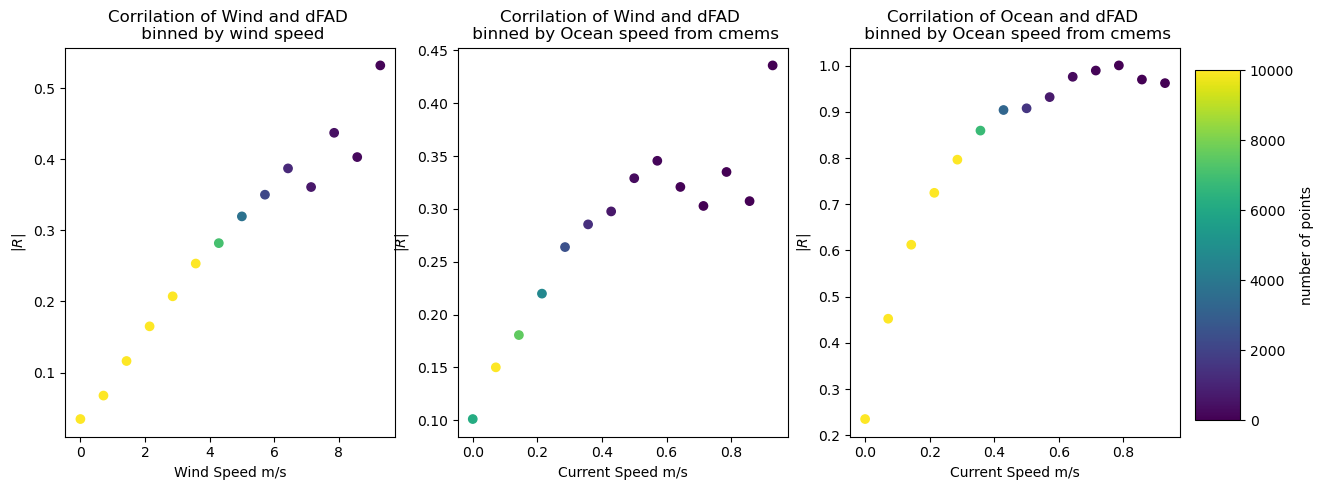

In [358]:
fig, ax = plt.subplots(1,3, figsize = (15,5))
cbar = ax[0].scatter(wind_range[bin_data.index.codes], np.abs(bin_data.values), c = bin_data_count)
ax[0].set(xlabel = "Wind Speed m/s", ylabel = '$|R|$')
#fig.colorbar(cbar, label = "Number of points")
cbar.set_clim(0,10000)
cbar = ax[1].scatter(current_range[bin_current_count.index.codes], np.abs(bin_current.values),c = bin_current_count)
ax[1].set(xlabel = "Current Speed m/s", ylabel = '$|R|$')
#fig.colorbar(cbar, label = "Number of points")
#cbar.set_clim(0,10000)
cbar = ax[2].scatter(current_range[bin_current_dFAD_count.index.codes], np.abs(bin_current_dFAD.values), c = bin_current_dFAD_count)
ax[2].set(xlabel = "Current Speed m/s", ylabel = '$|R|$')
#fig.colorbar(cbar, label = "Number of points")
cbar.set_clim(0,10000)

ax[0].set_title("Corrilation of Wind and dFAD \n binned by wind speed") 
ax[1].set_title("Corrilation of Wind and dFAD \n binned by Ocean speed from cmems")
ax[2].set_title("Corrilation of Ocean and dFAD \n binned by Ocean speed from cmems")
fig.tight_layout()
fig.subplots_adjust(right=0.79)
cbar_ax = fig.add_axes([0.80, 0.15, 0.03, 0.7]) # [left, bottom, width, height]
fig.colorbar(cbar, cax=cbar_ax, label = 'number of points')



### linear regression of to find leeway 
$$ leeway = \frac{ Windinducedspeed}{windspeed} $$

In [359]:
def fit_regression(W,U): 
    m, b = np.polyfit(W, U, 1)
    return (m,b)

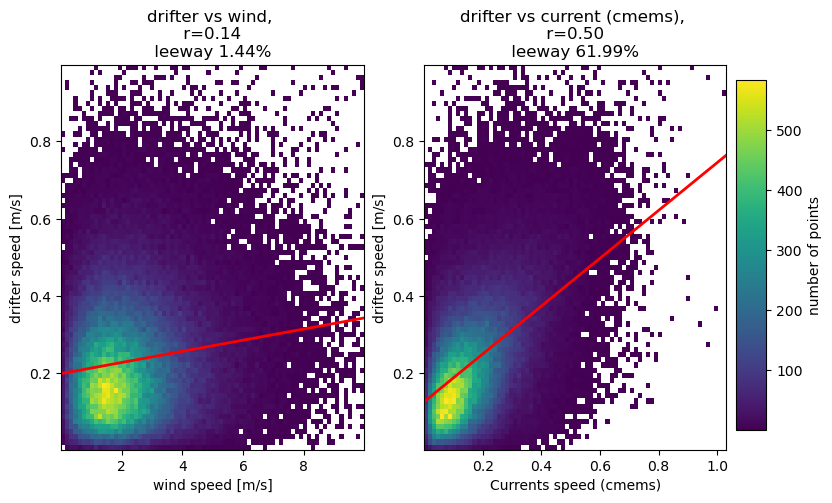

In [360]:
longlist_filtered = longlist2.query('W_mag < 10')
longlist_filtered = longlist_filtered.query('U_mag < 1')

m, b = np.polyfit(longlist_filtered.W_mag, longlist_filtered.U_mag, 1) ## Y = mx+b

mo, bo = np.polyfit(longlist_filtered.Uo_mag, longlist_filtered.U_mag,1)

W_mag = longlist_filtered.W_mag 
U_mag = longlist_filtered.U_mag
W = np.asarray(W_mag)
U = np.asarray(U_mag)

# Correlation (for title)
r = np.corrcoef(W, U)[0, 1]
ro = np.corrcoef(longlist_filtered.Uo_mag,longlist_filtered.U_mag)[0,1]
fig, ax = plt.subplots(1,2,figsize=(10,5))

# 2D histogram
ax[0].hist2d( W, U,bins=75,cmap="viridis",cmin = 1 , cmax = 600)
cbar = ax[1].hist2d( longlist_filtered.Uo_mag, longlist_filtered.U_mag,bins=75,cmap="viridis",cmin = 1, cmax = 600)

# Regression line
W_line = np.linspace(0, 20, 200)
U_line = m * W_line + b
ax[0].plot(W_line, U_line, color="red", linewidth=2)

Wo_line = np.linspace(0, 20, 200)
Uo_line = mo * W_line + bo
ax[1].plot(Wo_line, Uo_line, color="red", linewidth=2)


# Labels and limits
ax[0].set_xlabel("wind speed [m/s]")
ax[0].set_ylabel("drifter speed [m/s]")
ax[1].set(ylabel = "drifter speed [m/s]", xlabel = "Currents speed (cmems)")


# Title
ax[0].set_title(f"drifter vs wind, \n r={r:.2f} \n leeway {m*100 :.2f}% ")
ax[1].set_title(f"drifter vs current (cmems), \n r={ro:.2f} \n leeway {mo*100 :.2f}% ")

# Colorbar
fig.subplots_adjust(right=0.79)
cbar_ax = fig.add_axes([0.80, 0.15, 0.03, 0.7]) # [left, bottom, width, height]
fig.colorbar(cbar[3], cax=cbar_ax, label = 'number of points')

### regression in Vectore space 

$$U = Z*W  $$

W = wind 

U = dFAD 

"*" is conjacate
$$ Z = \frac {<W^* U>}{<W^* W>} $$
$$ leeway = |Z| $$
$$ deflection Angle = arg(z)$$

In [361]:
def Calc_Z(W,U):
    return np.mean(np.conj(W)*U)/np.mean(np.conj(W)*W)

In [362]:
### Regression in vector space 

Z = Calc_Z(longlist_filtered['W'], longlist_filtered['U'])
print("Regression between wind and drifter")
print(f" leeway  {np.abs( Z)*100:0.2f}% at angle of {np.angle(Z, deg=True)}\n")

Zc = Calc_Z(longlist_filtered['Uo'], longlist_filtered['U'])
print("Regression between currents and drifter")
print(f" leeway  {np.abs( Zc)*100:0.2f}% at angle of {np.angle(Zc, deg=True)}")

Regression between wind and drifter
 leeway  1.86% at angle of -25.631675082410236

Regression between currents and drifter
 leeway  80.04% at angle of 13.21481058567196


In [363]:
W_mag[W_mag >5].shape, W_mag.shape, U_mag.shape, U_mag[U_mag > 1].shape

((8415,), (167584,), (167584,), (0,))

In [456]:
## regresssion with complex numbers (differnt methtod) using numpy
U = longlist2.U
W = longlist2.W
Uo = longlist2.Uo
W_std = np.std(W)
Uo_std = np.std(Uo)

A = np.vstack([Uo/Uo_std,W/W_std, np.ones(len(Uo))]).T
B = U
coefficients, residuals, rank, singular_values = np.linalg.lstsq(A, B, rcond=None) #ridge regression 
m, mw, c = coefficients 

Uo_m = np.abs(m/Uo_std)
Uo_a = np.angle(m/Uo_std, deg=True)

W_m = np.abs(mw/W_std)
W_a = np.angle(mw/W_std, deg=True)

print((np.abs(m)*100).round(4), np.angle(m, deg=True).round(2))
print((np.abs(mw)*100).round(4), np.angle(mw, deg=True).round(2))
print((np.abs(c)*100).round(2), np.angle(c, deg=True).round(2))

print(f'Fraction of wind {(W_m/(W_m + Uo_m))*100}')
print(f'Fraction of Currents {(Uo_m/(W_m + Uo_m))*100}')


16.3547 11.84
2.1803 10.51
0.0 26.57
Fraction of wind 1.0006567540631217
Fraction of Currents 98.99934324593687


In [ ]:
def Regression(data):
    U = longlist2.U
    W = longlist2.W
    Uo = longlist2.Uo
    A = np.vstack([Uo, W, np.ones(len(Uo))]).T
    B = U
    coefficients, residuals, rank, singular_values = np.linalg.lstsq(A, B, rcond=None) #try ridge regression 
    return coefficients 

In [366]:
### Generated a regression model, Now How this regession compair to sinlge varaible regression, 
longlist_filtered["U_regres"]  = longlist_filtered.Uo*m #+ #longlist_filtered.W*mw + c
Z_reg = Calc_Z(longlist_filtered['U_regres'], longlist_filtered['U'])
print(f" leeway  {np.abs( Z_reg)*100:0.2f}% at angle of {np.angle(Z_reg, deg=True)}")
r = np.corrcoef(np.abs(longlist_filtered["U_regres"]), np.abs(longlist_filtered['U']))[0,1]
print(r) ## fits the Direction and magnitude perfectly but does not provide any more corrilation in the speeds themselves
R_reg = calc_R_anything(longlist_filtered['U'], longlist_filtered['U_regres'])
print(np.angle(R_reg, deg = True), np.abs(R_reg))

 leeway  99.61% at angle of 0.0028003531827891885
0.49609623247014595
-0.0028003531827890506 0.6072388505603572


In [367]:
import numpy as np

def complex_linear_regression(X_complex, y_complex):
    """
    Performs complex multiple linear regression using NumPy's lstsq.

    Args:
        X_complex (np.ndarray): A NumPy array of shape (n_samples, 2) 
                                containing the two independent complex variables.
        y_complex (np.ndarray): A NumPy array of shape (n_samples,) 
                                containing the dependent complex variable.

    Returns:
        np.ndarray: A NumPy array of the estimated complex coefficients 
                    [beta_0 (intercept), beta_1, beta_2].
    """
    # Add a column of ones to X for the intercept term (bias)
    ones = np.ones((X_complex.shape[0], 1), dtype=complex)
    X_design = np.hstack((ones, X_complex))

    # Use numpy.linalg.lstsq to solve for the coefficients
    # The 'rcond=None' is used to suppress a future warning
    coefficients, residuals, rank, singular_values = np.linalg.lstsq(
        X_design, y_complex, rcond=None
    )
    
    return coefficients

X_data = np.vstack((W, Uo)).T # Shape (m, 2)



# 2. Perform regression
estimated_betas = complex_linear_regression(X_data, U)

print(f"Estimated coefficients: {estimated_betas}")
print(f"B_o : magnitude:{np.abs(estimated_betas[0])*100: 0.4f}% angle: {np.angle(estimated_betas[0], deg= True)}:0.2f")
print(f"W : magnitude:{np.abs(estimated_betas[1])*100:.2f}% angle: {np.angle(estimated_betas[1], deg= True):.2f} deg")
print(f"Uo : magnitude:{np.abs(estimated_betas[2])*100:.2f}% angle: {np.angle(estimated_betas[2], deg= True):.2f} deg")


Estimated coefficients: [3.47274359e-19-8.47010633e-20j 7.85629581e-03+1.45730160e-03j
 7.73709253e-01+1.62143540e-01j]
B_o : magnitude: 0.0000% angle: -13.70696100407981:0.2f
W : magnitude:0.80% angle: 10.51 deg
Uo : magnitude:79.05% angle: 11.84 deg


In [368]:
a = 1 + 1j
b = 1+2j
print(a, np.angle(a, deg = True), np.abs(a)) ## regression of the wind product
print(m, np.angle(m, deg = True), np.abs(m)) ## regression of the wind product
c2 = a*m 
print(c2, np.angle(c2, deg = True), np.abs(c2))

(1+1j) 45.0 1.4142135623730951
(0.7822677629851388+0.18365225418914569j) 13.212010232489172 0.8035365601355845
(0.5986155087959931+0.9659200171742844j) 58.21201023248917 1.1363723012063676


In [369]:
## lets produce a table of our results for regresion on all of the data 
# row: r, s, |R|, Phase(R), |Z|, Phase |Z| 
## Columns = Wind vs drifter, Ocean Vs drifter, Regression of Vs drifter 

def Generate_Corrilation_Table(dataframe, coefficients):
      output = pd.DataFrame(columns = ["Wind", "Currents", "Regression"], index= ['Data', 'r', 's', '|R|', 'Phase(R)', '|Z|', 'Phase(Z)'])
      output.loc['Data'] = ["ERA5", "CMEMS", "CMEMS + ERA5"]
      op = dataframe.copy()

      m, mw, c = coefficients 
      op["U_regres"]  = op.Uo*m + op.W*mw + c

      output.loc['r'] = [ np.corrcoef(np.abs(op.W), np.abs(op.U))[0,1].round(3),
                        np.corrcoef(np.abs(op.Uo), np.abs(op.U))[0,1].round(3),
                        np.corrcoef(np.abs(op.U_regres), np.abs(op.U))[0,1].round(3)]

      ss = [fit_regression(np.abs(op.W),np.abs(op.U) )[0].round(3),
            fit_regression(np.abs(op.Uo),np.abs(op.U) )[0].round(3), 
            fit_regression(np.abs(op.U_regres),np.abs(op.U) )[0].round(3) ]
      output.loc['s'] = ss

      Rs = [ calc_R_anything(op.W, op.U),
            calc_R_anything(op.Uo, op.U), 
            calc_R_anything(op.U_regres, op.U) ]

      output.loc['|R|'] = np.abs(Rs).round(3)
      output.loc['Phase(R)'] = np.angle(Rs, deg = True).round(2)

      Zs = [Calc_Z(op.W, op.U), Calc_Z(op.Uo, op.U), Calc_Z(op.U_regres, op.U)]
      output.loc['|Z|'] = np.abs(Zs).round(3)
      output.loc['Phase(Z)'] = -np.angle(Zs, deg = True).round(2)
      return output
targettime = pd.Timestamp("2024-01-01")
longlist2223 = longlist2.query("time < @targettime")
longlist2024 = longlist2.query("time > @targettime")
coefficients = Regression(longlist2)
output = Generate_Corrilation_Table(longlist2, coefficients)

In [370]:
print(coefficients)
output

[7.73709253e-01+1.62143540e-01j 7.85629581e-03+1.45730160e-03j
 2.03282552e-19+4.74325954e-19j]


,Wind,Currents,Regression
Data,ERA5,CMEMS,CMEMS + ERA5
r,0.148,0.495,0.496
s,0.015,0.625,0.783
|R|,0.187,0.607,0.612
Phase(R),-25.21,13.21,-0.0
|Z|,0.019,0.804,1.0
Phase(Z),25.21,-13.21,0.0


In [371]:
def Yearly_R_values(data):
    output = pd.DataFrame( index= ['Data', 'r', 's', '|R|', 'Phase(R)', '|Z|', 'Phase(Z)'])
    data["time"] = pd.to_datetime(data["time"])
    startdate  = pd.Timestamp("2022-01-01")
    coefficients = Regression(data)
    for n in range(3):
        print(startdate)
        timedelta = pd.Timedelta(365, "days")
        enddate = startdate + timedelta
        regression_data = data[~data.time.between(startdate, enddate)]
        coefficients = Regression(regression_data)
        print(coefficients)
        year = data.query("time > @startdate")
        year = year.query("time < @enddate")
        output_temp = Generate_Corrilation_Table(year, coefficients= coefficients)
        y = startdate.year
        #output_temp = output_temp.rename(columns= {"Wind": f"Wind {y}", "Currents": f"Currents {y}", "Regression": f"Regression {y}"})
        output_temp.loc['year'] = y
        output = pd.concat([output, output_temp], axis= 1)
        startdate = enddate
    return output

def Lat_R_values(data):
    output = pd.DataFrame( index= ['Data', 'r', 's', '|R|', 'Phase(R)', '|Z|', 'Phase(Z)'])
    data["time"] = pd.to_datetime(data["time"])
    latrange  = np.arange(4.5,7.5, 0.25)
    coefficients = Regression(data)
    for n in range(len(latrange)-1):
        #print(latrange[n], latrange[n+1])
        lowerlat, upperlat =latrange[n], latrange[n+1]
        year = data.query("lat > @lowerlat")
        year = year.query("lat < @upperlat")
        output_temp = Generate_Corrilation_Table(year, coefficients= coefficients)
        y = latrange[n]
        #output_temp = output_temp.rename(columns= {"Wind": f"Wind ", "Currents": f"Currents {y}", "Regression": f"Regression {y}"})
        output_temp.loc["lat"] = lowerlat
        output = pd.concat([output, output_temp], axis= 1)

    return output

latrs = Lat_R_values(longlist2)
yearrs = Yearly_R_values(longlist2)

2022-01-01 00:00:00
[7.73709253e-01+1.62143540e-01j 7.85629581e-03+1.45730160e-03j
 2.03282552e-19+4.74325954e-19j]
2023-01-01 00:00:00
[7.73709253e-01+1.62143540e-01j 7.85629581e-03+1.45730160e-03j
 2.03282552e-19+4.74325954e-19j]
2024-01-01 00:00:00
[7.73709253e-01+1.62143540e-01j 7.85629581e-03+1.45730160e-03j
 2.03282552e-19+4.74325954e-19j]


In [372]:
yearrs.to_csv(r"Data\Wind_corrilations_yearly.csv")
yearrs

,Wind,Currents,Regression,Wind,Currents,Regression,Wind,Currents,Regression
Data,ERA5,CMEMS,CMEMS + ERA5,ERA5,CMEMS,CMEMS + ERA5,ERA5,CMEMS,CMEMS + ERA5
r,0.08,0.33,0.328,0.192,0.482,0.49,0.124,0.495,0.495
s,0.009,0.411,0.515,0.016,0.647,0.807,0.013,0.646,0.807
|R|,0.066,0.484,0.484,0.246,0.618,0.625,0.186,0.612,0.617
Phase(R),-34.89,12.37,-0.15,-24.03,13.23,-0.7,-18.15,15.44,2.43
|Z|,0.007,0.642,0.803,0.021,0.847,1.038,0.019,0.825,1.026
Phase(Z),34.89,-12.37,0.15,24.03,-13.23,0.7,18.15,-15.44,-2.43
year,2022,2022,2022,2023,2023,2023,2024,2024,2024


In [460]:
import xarray as xr
test = xr.open_dataset(r"Data\regression_quantiles.nc")

In [467]:
test.initial_speed_dif_mag[:,:].values

array([[ 5.98704579,  9.32780452, 10.47745145, 11.17440841, 11.66965907,
        12.09996725, 12.29771257, 12.7563909 , 12.9870028 ],
       [11.40819682, 12.65680895, 13.68380579, 15.62828665, 18.80516563,
        21.02902924, 22.96224531, 24.02150187, 25.40975362],
       [19.83980432, 22.45590844, 24.06544188, 25.85797287, 27.57077662,
        29.58725151, 31.53271358, 33.79080047, 36.2394316 ],
       [25.07363454, 29.14908736, 31.81021824, 34.67002514, 36.74343031,
        38.1033055 , 40.38449272, 42.77046136, 46.28850227],
       [28.06259846, 34.09844997, 39.05435649, 42.1395834 , 44.70346581,
        47.03392152, 49.16036376, 51.79086967, 55.50868806]])

           Data      r      s    |R| Phase(R)    |Z| Phase(Z)  year
Currents  CMEMS   0.33  0.411  0.484    12.37  0.642   -12.37  2022
Currents  CMEMS  0.482  0.647  0.618    13.23  0.847   -13.23  2023
Currents  CMEMS  0.495  0.646  0.612    15.44  0.825   -15.44  2024


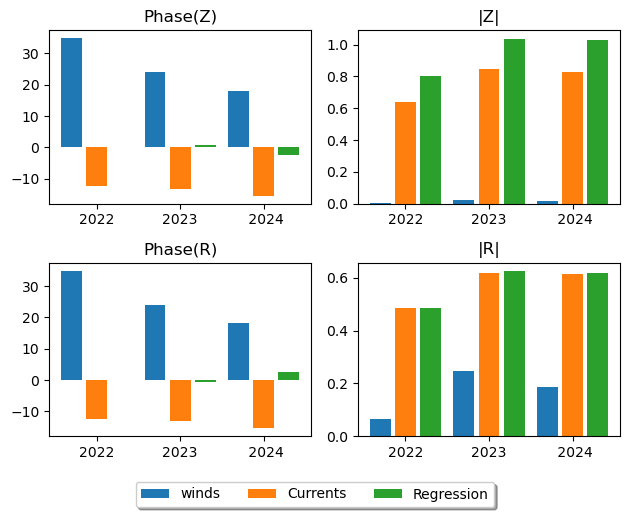

In [373]:
latT = latrs.T
yearsT= yearrs.T 
WT = yearsT.query("index == 'Wind'")
CT = yearsT.query("index == 'Currents'")
RT = yearsT.query("index == 'Regression'")
print(CT)
fig, ax = plt.subplots(2,2)
xspots = np.array([0,1,2])
xlabels = ["2022", '2023', ' 2024']
width = 0.3
ax[0,0].bar(xspots- width, WT['Phase(Z)'], width= 0.25, label = "winds")
ax[0,0].bar(xspots, CT['Phase(Z)'], width =0.25, label = "Currents")
ax[0,0].bar(xspots +width, RT['Phase(Z)'], width =0.25, label = "Regression")

ax[0,1].bar(xspots- width, WT['|Z|'], width= 0.25)
ax[0,1].bar(xspots, CT['|Z|'], width =0.25)
ax[0,1].bar(xspots +width, RT['|Z|'], width =0.25)

ax[1,0].bar(xspots- width, -WT['Phase(R)'], width= 0.25)
ax[1,0].bar(xspots,  -CT['Phase(R)'], width =0.25)
ax[1,0].bar(xspots +width, RT['Phase(R)'], width =0.25)

ax[1,1].bar(xspots- width, WT['|R|'], width= 0.25)
ax[1,1].bar(xspots, CT['|R|'], width =0.25)
ax[1,1].bar(xspots +width, RT['|R|'], width =0.25)

ax[0,0].set(title = "Phase(Z)",  xticks = xspots, xticklabels = xlabels)
ax[0,1].set(title = "|Z|",  xticks = xspots, xticklabels = xlabels)
ax[1,0].set(title = "Phase(R)", xticks = xspots, xticklabels = xlabels)
ax[1,1].set(title = "|R|",  xticks = xspots, xticklabels = xlabels)
fig.tight_layout()
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0),
          fancybox=True, shadow=True, ncol=5)

In [ ]:
import functions.funcs as func

func.haversine_df()

In [439]:
## calc R for each dFAD with at least 5 points
def merge_forecast_true(fc, longlist):
    merged = pd.merge_asof(
    fc.sort_values('time'),
    longlist.sort_values('time'),
    on='time',
    by='BuoyID',
    tolerance=pd.Timedelta(minutes=1),
    direction='nearest'
    )
    return merged

fc = pd.read_csv(r'Parcels\saved_output\cmems_dynamical2024.csv').rename(columns= {'Time': 'time'})
fc['time'] = pd.to_datetime(fc.time)
merged_errors = merge_forecast_true(fc,longlist2)
merged_errors['error_km'] = func.haversine_df(merged_errors, "lat_true", "lon_true", "lat_forcast", "lon_forcast")
 
BuoyR = merged_errors.groupby("BuoyID",).apply(calc_R, include_groups=False).to_frame(name = "R")
BuoyR['numpoints'] = merged_errors.groupby("BuoyID",).BuoyID.count()
merged_errors['lead_bins'] = pd.cut(merged_errors.leadtime, np.linspace(0,8*24,2*24+1))
bin = merged_errors.lead_bins.unique().sort_values()[18]
BuoyR['error72'] = merged_errors.query('lead_bins == @bin').groupby('BuoyID')['error_km'].mean()
BuoyR["|R|"] = np.abs(BuoyR.R)
BuoyR["phaseR"] = np.angle(BuoyR.R,deg = True)
BouyR_org = BuoyR.copy()
BuoyR = BuoyR.query('numpoints > 10')
print(BuoyR)


                             R  numpoints    error72       |R|      phaseR
BuoyID                                                                    
ISD+496035  0.262883-0.529065j         56        NaN  0.590777  -63.578020
ISD+496037 -0.184736-0.406150j         44  68.320170  0.446190 -114.458286
ISD+496040  0.054587-0.621844j         39        NaN  0.624236  -84.983311
ISD+496043  0.185553+0.127439j         16        NaN  0.225101   34.481566
ISD+496044  0.107264+0.215202j         85  68.603556  0.240453   63.506718
...                        ...        ...        ...       ...         ...
SLX+502556  0.311746+0.061639j        208  61.923557  0.317781   11.184341
SLX+502558  0.180607-0.111306j        545  76.005538  0.212151  -31.644960
SLX+502560  0.274132+0.016952j         33        NaN  0.274656    3.538559
SLX+502582  0.323084+0.030764j         84  73.323819  0.324546    5.439237
SLX+509310  0.499454+0.071401j        215  68.057416  0.504532    8.135728

[747 rows x 5 columns]


[Text(0.5, 0, 'Phase(R)')]

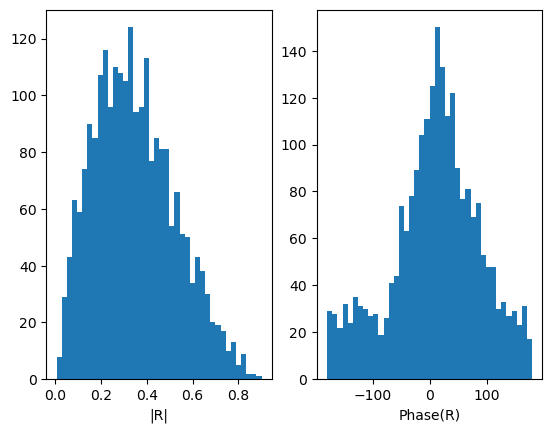

In [418]:
fig, ax = plt.subplots(1,2)
ax[0].hist(BuoyR['|R|'], bins = 40)
ax[1].hist(BuoyR['phaseR'], bins = 40)
ax[0].set(xlabel = '|R|')
ax[1].set(xlabel = 'Phase(R)')

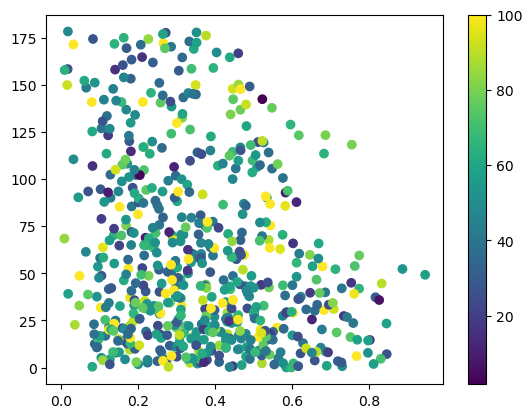

In [445]:
## adding Forecast errors at 72 hours. 

fig,ax = plt.subplots()
cbar  = ax.scatter(BuoyR['|R|'], np.abs(BuoyR['phaseR']), c = BuoyR.error72, vmax = 100)
fig.colorbar(cbar)


